## SMS SPAM CLASSIFIER

In [1]:
## Importing Libraries
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 679.8 KB


In [5]:
# Drop Last 3 columns which are not required
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [6]:
df.sample(5)

,v1,v2
2287,ham,Alex knows a guy who sells mids but he's down ...
2267,ham,Finish liao... U?
2232,ham,Nothing just getting msgs by dis name wit diff...
4675,ham,ï¿½ï¿½ ready then call me...
1287,ham,"What do you do, my dog ? Must I always wait ti..."


In [7]:
# Renaming the columns for better understanding
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [8]:
# Label Encoding the target column
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [9]:
# Checking for null values
df.isnull().sum()

target    0
text      0
dtype: int64

In [10]:
# Check for duplicate values
df.duplicated().sum()

# remove duplicate values
df = df.drop_duplicates(keep='first')

In [11]:
df.shape

(5169, 2)

## EDA

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

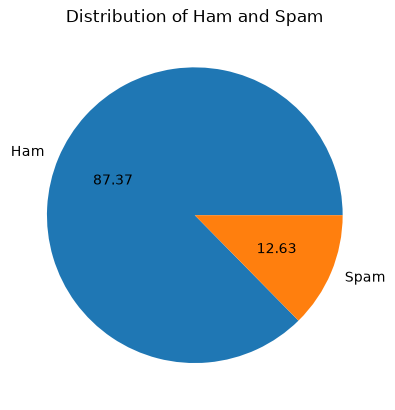

In [14]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['Ham', 'Spam'], autopct="%0.2f")
plt.title('Distribution of Ham and Spam')
plt.show()

In [15]:
# installing nltk dependencies
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahuk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sahuk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [16]:
df['num_characters'] = df['text'].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
# num of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [18]:
# num of sentences
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [19]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.00000,5169.000000,5169.000000
mean,79.23196,18.455794,1.965564
std,58.33921,13.324758,1.448541
min,2.00000,1.000000,1.000000
25%,36.00000,9.000000,1.000000
50%,61.00000,15.000000,1.000000
75%,117.00000,26.000000,2.000000
max,910.00000,220.000000,38.000000


In [20]:
# for ham messages
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()




,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.684234,17.123782,1.820195
std,56.435582,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [21]:
# for spam messages
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,138.346095,27.667688,2.970904
std,30.261787,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,158.000000,32.000000,4.000000
max,225.000000,46.000000,9.000000


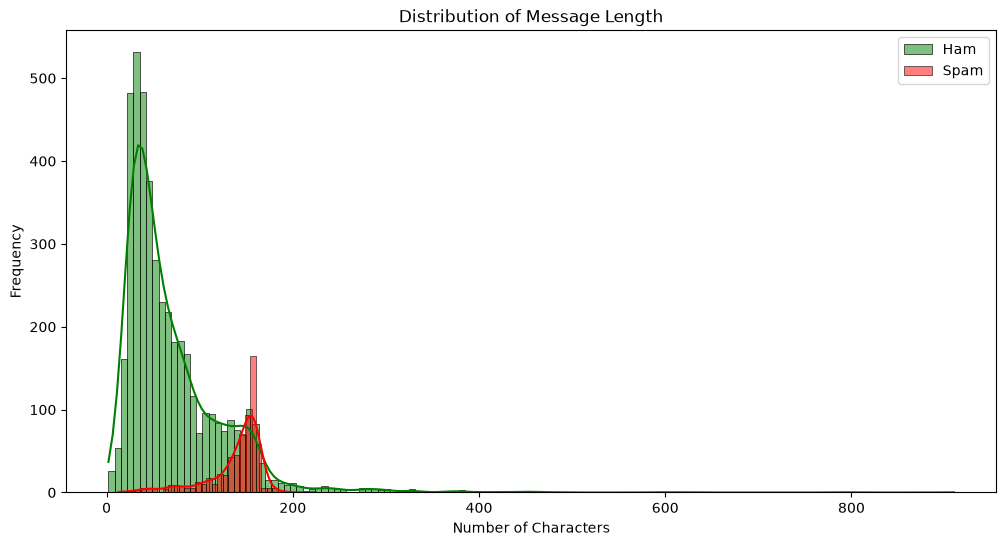

In [22]:
# histogram for spam and ham messages
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'], color='green', label='Ham', kde=True)
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam', kde=True)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Distribution of Message Length')
plt.legend()
plt.show()

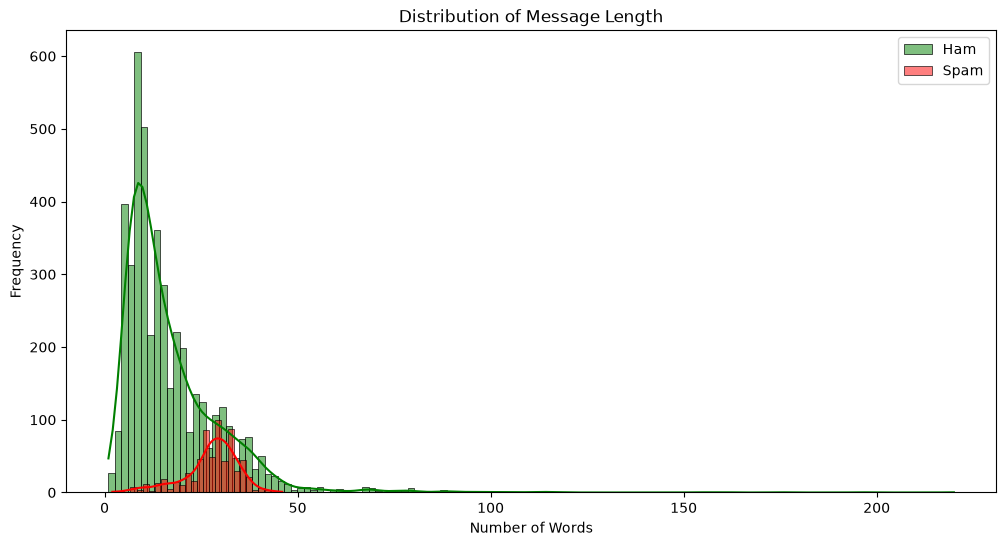

In [23]:

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'], color='green', label='Ham', kde=True)
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Spam', kde=True)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Message Length')
plt.legend()
plt.show()

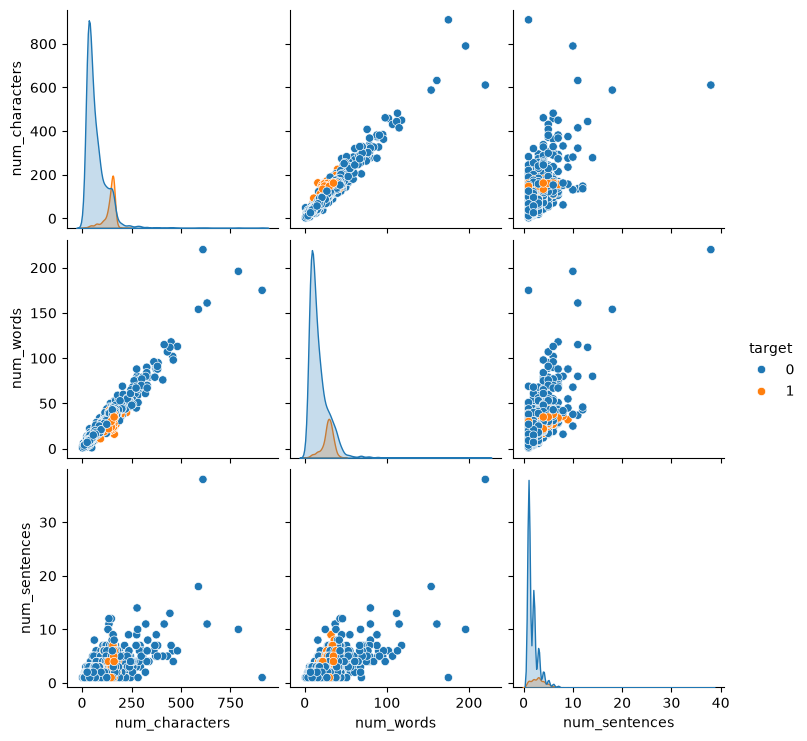

In [24]:
# Correlation between the features
sns.pairplot(df, hue='target')

<Axes: >

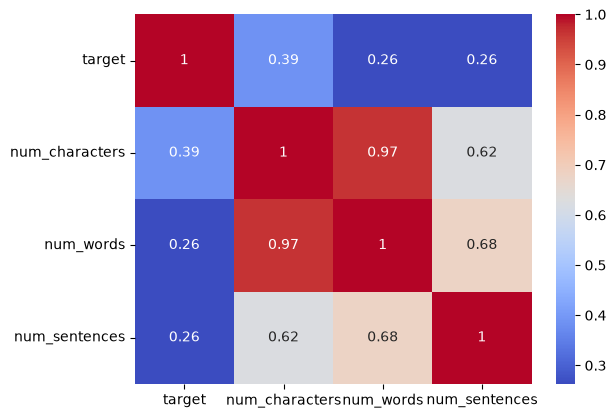

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

## Text Preprocessing

In [26]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')    # for newer NLTK versions
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahuk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sahuk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahuk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
from nltk.corpus import stopwords
import string
# Stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    text = y[:]
    
    return " ".join(y)

In [28]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


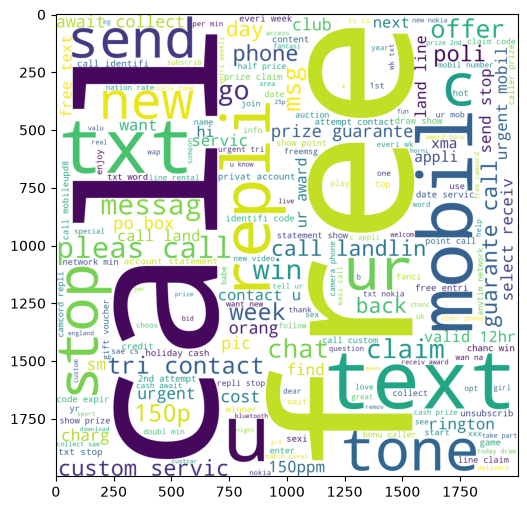

In [29]:
# for futher processing we will use the transformed_text column instead of text column and target column instead of v1 column. So we will drop the text column and rename the target column to label.
# generating world cloud for the transformed_text column

from wordcloud import WordCloud
wc = WordCloud(width=2000, height=2000, min_font_size=10, background_color='white')

# spam_wc = wc.copy()
spam_wc =wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

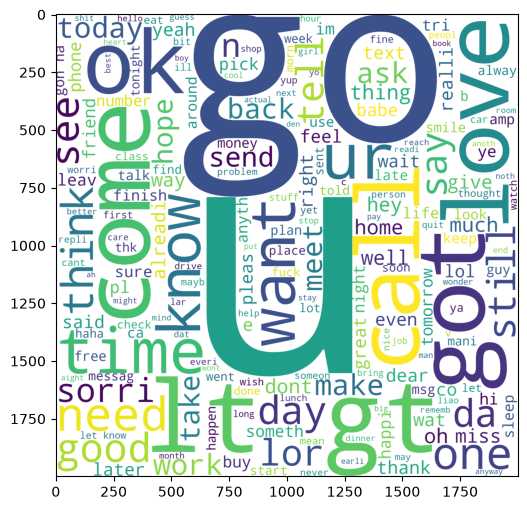

In [30]:
ham_wc =wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)


In [31]:
# Top 30 words in spam messages
spam_words = []
for message in df[df['target'] == 1]['transformed_text'].tolist():
    for word in message.split():
        spam_words.append(word)

len(spam_words)

9936

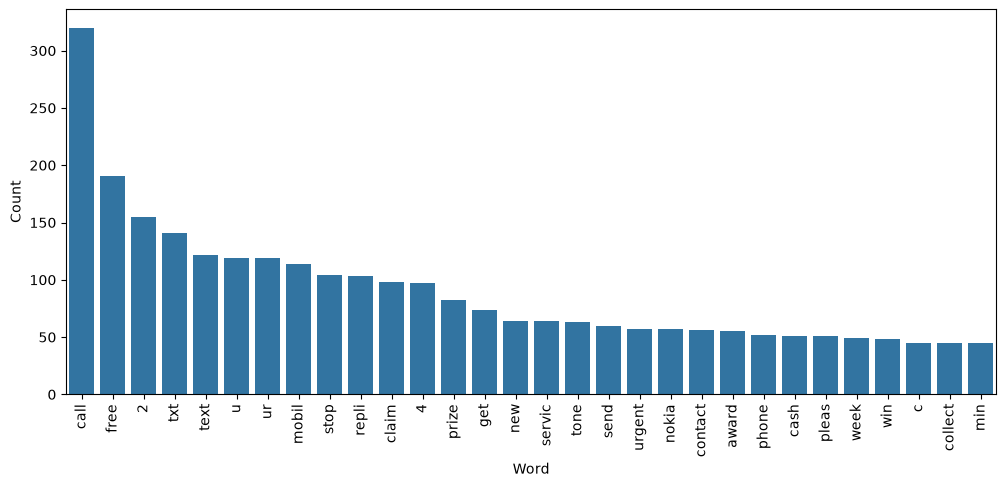

In [ ]:
from collections import Counter

word_df = pd.DataFrame(
    Counter(spam_words).most_common(30),
    columns=["Word", "Count"]
)

plt.figure(figsize=(12,5))
sns.barplot(data=word_df, x="Word", y="Count")

plt.xticks(rotation=90)
plt.show()

In [34]:
# Top 30 words in ham messages
ham_words = []
for message in df[df['target'] == 0]['transformed_text'].tolist():
    for word in message.split():
        ham_words.append(word)

len(ham_words)

35305

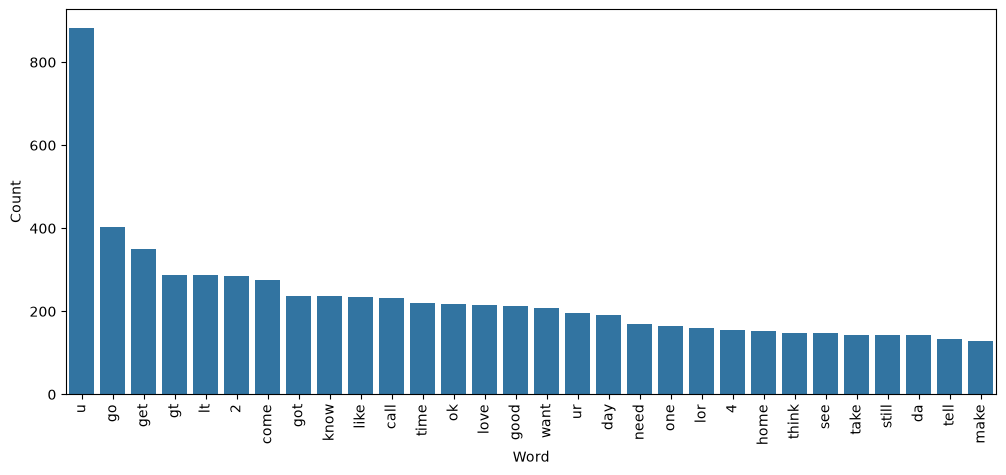

In [36]:
from collections import Counter

word_df = pd.DataFrame(
    Counter(ham_words).most_common(30),
    columns=["Word", "Count"]
)

plt.figure(figsize=(12,5))
sns.barplot(data=word_df, x="Word", y="Count")

plt.xticks(rotation=90)
plt.show()

## Model Training